In [1]:
import os
print(os.listdir("/kaggle/input")) 

['datasets']


In [2]:
data_dir = "/kaggle/input/datasets/tannurawat32/split-data/split_data" 

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader 

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
]) 

In [6]:
train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(f"{data_dir}/val", transform=val_transform) 

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
) 

In [8]:
model = models.mobilenet_v2(weights="IMAGENET1K_V1")

num_classes = len(train_dataset.classes)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)   

In [9]:
for param in model.features.parameters():
    param.requires_grad = False  

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  

In [11]:
best_val_acc = 0  

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total
    
def train_model(model, train_loader, val_loader, epochs=5,
                train_acc_list=None, val_acc_list=None, loss_list=None):

    global best_val_acc

    # Initialize lists
    if train_acc_list is None:
        train_acc_list = []
    if val_acc_list is None:
        val_acc_list = []
    if loss_list is None:
        loss_list = []

    print("Training started")

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Track loss
            running_loss += loss.item() * images.size(0)

            # Predictions
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # Calculate metrics
        train_acc = correct / total
        epoch_loss = running_loss / total
        val_acc = evaluate(model, val_loader)

        # Store results
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        loss_list.append(epoch_loss)

        # Print progress
        print(f"Epoch {len(train_acc_list)}")
        print(f"Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print("-" * 40)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "/kaggle/working/best_Food_model.pth")

    return train_acc_list, val_acc_list, loss_list


In [12]:
train_acc, val_acc, loss = train_model(model, train_loader, val_loader, epochs=5)  

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1
Loss: 2.5018 | Train Acc: 0.4427 | Val Acc: 0.5906
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2
Loss: 1.5602 | Train Acc: 0.6045 | Val Acc: 0.6251
----------------------------------------


...

Epoch 3
Loss: 1.3021 | Train Acc: 0.6558 | Val Acc: 0.6711
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 4
Loss: 1.1880 | Train Acc: 0.6795 | Val Acc: 0.6843
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 5
Loss: 1.0992 | Train Acc: 0.6973 | Val Acc: 0.6740
----------------------------------------


In [13]:
for param in model.features.parameters():
    param.requires_grad = True  

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  

In [15]:
train_acc, val_acc, loss = train_model(
    model, train_loader, val_loader,
    epochs=5,
    train_acc_list=train_acc,
    val_acc_list=val_acc,
    loss_list=loss
)

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 6
Loss: 0.8404 | Train Acc: 0.7614 | Val Acc: 0.7734
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 7
Loss: 0.5736 | Train Acc: 0.8341 | Val Acc: 0.7918
----------------------------------------


...

Epoch 8
Loss: 0.4374 | Train Acc: 0.8753 | Val Acc: 0.7913
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 9
Loss: 0.3254 | Train Acc: 0.9095 | Val Acc: 0.8056
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10
Loss: 0.2678 | Train Acc: 0.9227 | Val Acc: 0.8125
----------------------------------------


In [16]:
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, num_classes)
)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)

In [17]:
train_acc, val_acc, loss = train_model(
    model, train_loader, val_loader,
    epochs=3,  
    train_acc_list=train_acc,
    val_acc_list=val_acc,
    loss_list=loss
) 

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 11
Loss: 1.9915 | Train Acc: 0.5741 | Val Acc: 0.6998
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 12
Loss: 1.0143 | Train Acc: 0.7507 | Val Acc: 0.7717
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 13
Loss: 0.6840 | Train Acc: 0.8292 | Val Acc: 0.7878
----------------------------------------


In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)  

In [19]:
train_acc, val_acc, loss = train_model(
    model, train_loader, val_loader,
    epochs=2,
    train_acc_list=train_acc,
    val_acc_list=val_acc,
    loss_list=loss
) 

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14
Loss: 0.4756 | Train Acc: 0.8903 | Val Acc: 0.8085
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 15
Loss: 0.4316 | Train Acc: 0.9020 | Val Acc: 0.8137
----------------------------------------


In [22]:
train_acc, val_acc, loss = train_model(
    model, train_loader, val_loader,
    epochs=3,
    train_acc_list=train_acc,
    val_acc_list=val_acc,
    loss_list=loss
) 

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 16
Loss: 0.4097 | Train Acc: 0.9044 | Val Acc: 0.8194
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 17
Loss: 0.3902 | Train Acc: 0.9130 | Val Acc: 0.8286
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 18
Loss: 0.3621 | Train Acc: 0.9222 | Val Acc: 0.8240
----------------------------------------


In [25]:
train_acc, val_acc, loss = train_model(
    model, train_loader, val_loader,
    epochs=2,
    train_acc_list=train_acc,
    val_acc_list=val_acc,
    loss_list=loss
) 

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 19
Loss: 0.3457 | Train Acc: 0.9280 | Val Acc: 0.8275
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 20
Loss: 0.3344 | Train Acc: 0.9281 | Val Acc: 0.8258
----------------------------------------


In [28]:
train_acc, val_acc, loss = train_model(
    model, train_loader, val_loader,
    epochs=2,
    train_acc_list=train_acc,
    val_acc_list=val_acc,
    loss_list=loss
)

Training started


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 21
Loss: 0.3161 | Train Acc: 0.9304 | Val Acc: 0.8390
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 22
Loss: 0.3059 | Train Acc: 0.9321 | Val Acc: 0.8292
----------------------------------------


In [29]:
test_dataset = datasets.ImageFolder(f"{data_dir}/test", transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [30]:
test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc) 

Test Accuracy: 0.8111233480176211


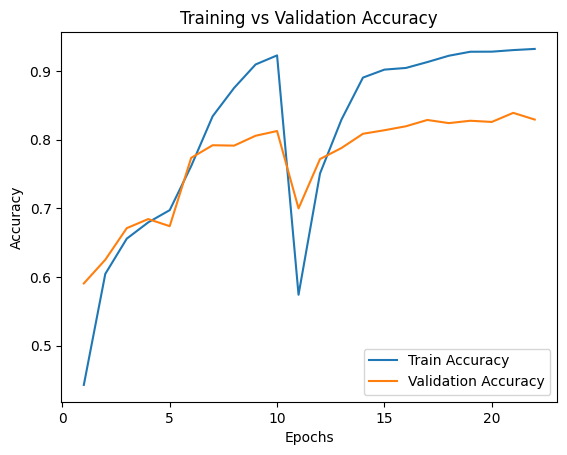

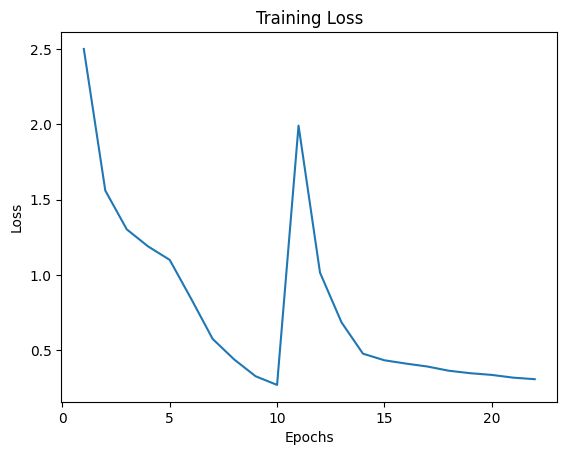

In [31]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc) + 1)

# Accuracy
plt.figure()
plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


# Loss 
plt.figure()
plt.plot(epochs, loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

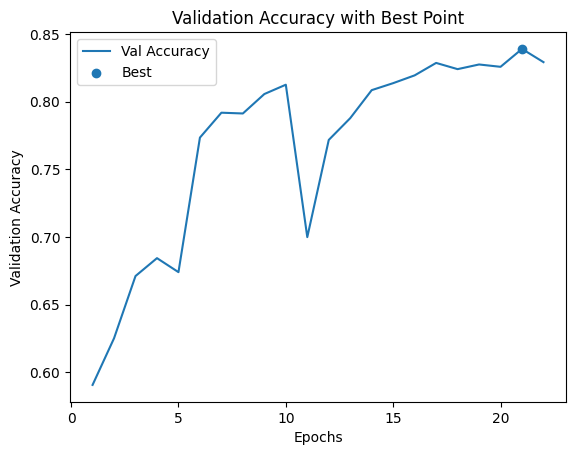

In [32]:
best_epoch = val_acc.index(max(val_acc)) + 1
best_val = max(val_acc)

plt.figure()
plt.plot(epochs, val_acc)
plt.scatter(best_epoch, best_val)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy with Best Point")
plt.legend(["Val Accuracy", "Best"])
plt.show()

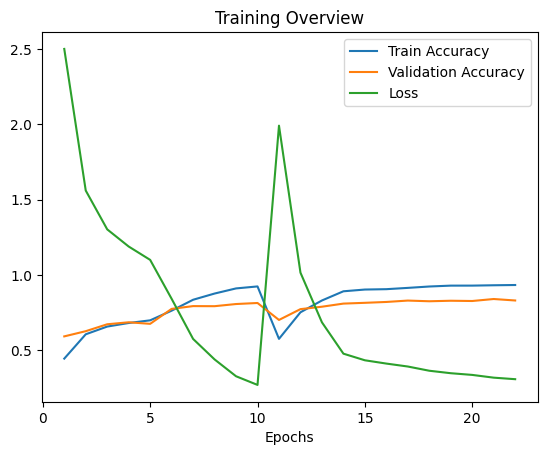

In [33]:
plt.figure()

plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.plot(epochs, loss)

plt.xlabel("Epochs")
plt.title("Training Overview")

plt.legend(["Train Accuracy", "Validation Accuracy", "Loss"])
plt.show()

In [34]:
import torch

def get_predictions(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

In [35]:
from sklearn.metrics import classification_report, accuracy_score

y_true, y_pred = get_predictions(model, test_loader)

# Accuracy
test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)

# Full report
print(classification_report(y_true, y_pred, target_names=test_dataset.classes))

Test Accuracy: 0.8111233480176211
                              precision    recall  f1-score   support

                   adhirasam       0.75      0.75      0.75         8
                   aloo_gobi       0.92      0.92      0.92        38
                  aloo_matar       0.75      0.38      0.50         8
                  aloo_methi       0.83      0.62      0.71         8
           aloo_shimla_mirch       0.70      0.88      0.78         8
                  aloo_tikki       0.57      0.50      0.53         8
                      anarsa       0.50      0.50      0.50         8
                     ariselu       0.55      0.75      0.63         8
                bandar_laddu       0.71      0.62      0.67         8
                     basundi       0.36      0.50      0.42         8
                     bhatura       1.00      0.50      0.67         8
               bhindi_masala       0.91      0.99      0.94        68
                     biryani       0.91      1.00      

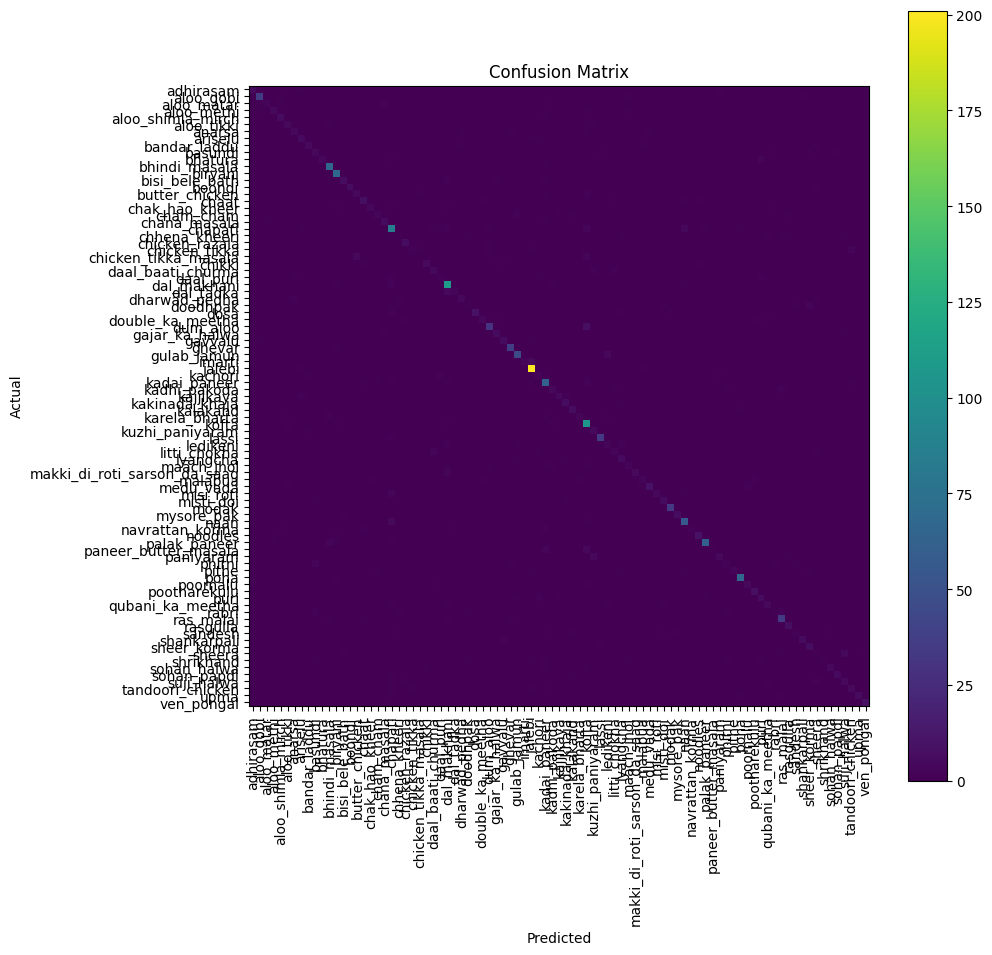

In [36]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

classes = test_dataset.classes

plt.figure(figsize=(10,10))
plt.imshow(cm)

plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()

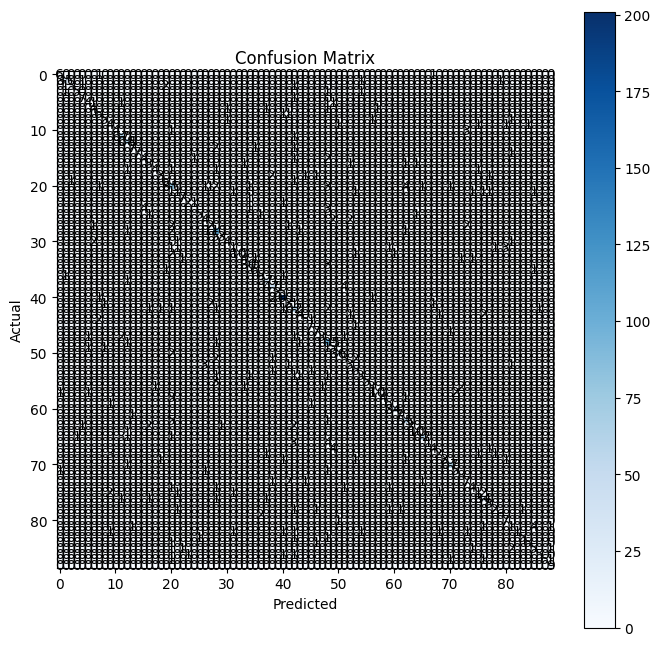

In [37]:
plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.colorbar()
plt.show()

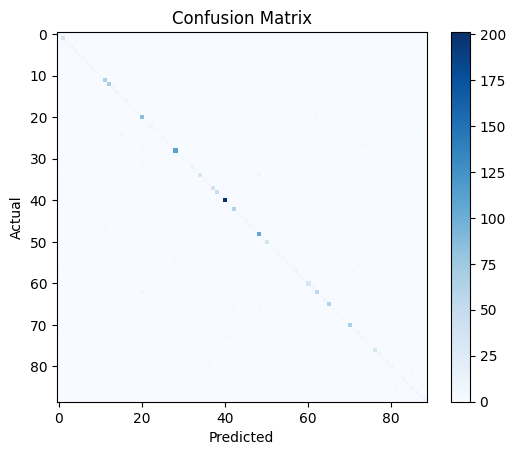

In [38]:
plt.figure()
plt.imshow(cm, cmap="Blues")   
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8090536224505758
Recall: 0.8111233480176211
F1 Score: 0.7981695489236091


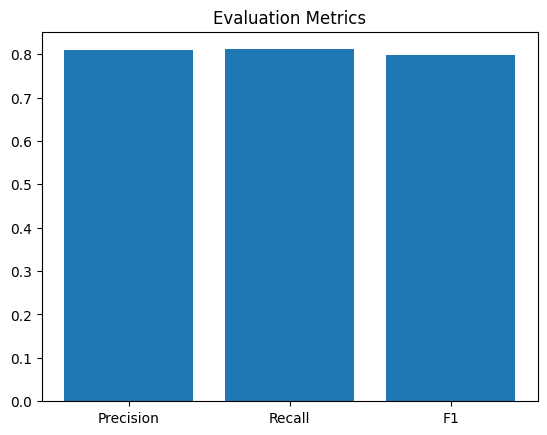

In [41]:
metrics = [precision, recall, f1]

plt.figure()
plt.bar(["Precision", "Recall", "F1"], metrics)
plt.title("Evaluation Metrics")
plt.show()

In [42]:
import numpy as np

classes = test_dataset.classes

confusions = []

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:
            confusions.append((classes[i], classes[j], cm[i][j]))


confusions_sorted = sorted(confusions, key=lambda x: x[2], reverse=True)

print("\nMost Confused Class Pairs:")
for i in range(10):
    print(confusions_sorted[i])


Most Confused Class Pairs:
('dum_aloo', 'kofta', np.int64(8))
('dal_tadka', 'dal_makhani', np.int64(5))
('imarti', 'jalebi', np.int64(5))
('naan', 'chapati', np.int64(5))
('chapati', 'naan', np.int64(4))
('chicken_tikka_masala', 'butter_chicken', np.int64(4))
('gulab_jamun', 'ledikeni', np.int64(4))
('paneer_butter_masala', 'kofta', np.int64(4))
('paniyaram', 'kuzhi_paniyaram', np.int64(4))
('sheera', 'suji_halwa', np.int64(4))


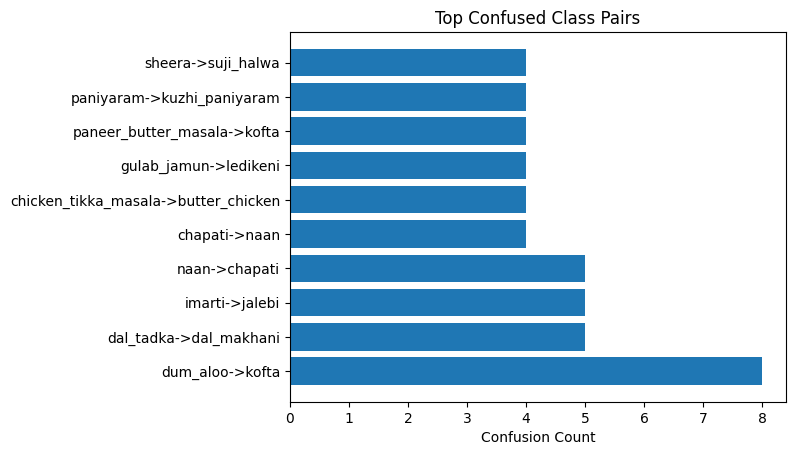

In [43]:
top_pairs = confusions_sorted[:10]

labels = [f"{a}->{b}" for a,b,_ in top_pairs]
values = [v for _,_,v in top_pairs]

plt.figure()
plt.barh(labels, values)
plt.title("Top Confused Class Pairs")
plt.xlabel("Confusion Count")
plt.show()

In [44]:

report = classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    output_dict=True
)

In [45]:
# store (class, f1-score)
f1_scores = []

for class_name in test_dataset.classes:
    f1 = report[class_name]["f1-score"]
    f1_scores.append((class_name, f1))

# sort
f1_scores_sorted = sorted(f1_scores, key=lambda x: x[1], reverse=True)

# top 10 best
top10 = f1_scores_sorted[:10]

# bottom 10 worst
bottom10 = f1_scores_sorted[-10:]

print("\nTop 10 Best Classes:")
for name, score in top10:
    print(name, "→", round(score, 3))

print("\nTop 10 Worst Classes:")
for name, score in bottom10:
    print(name, "→", round(score, 3))


Top 10 Best Classes:
modak → 0.986
poha → 0.971
jalebi → 0.966
biryani → 0.951
ghevar → 0.949
lassi → 0.947
bhindi_masala → 0.944
palak_paneer → 0.939
boondi → 0.933
aloo_gobi → 0.921

Top 10 Worst Classes:
sandesh → 0.333
daal_puri → 0.308
phirni → 0.308
paneer_butter_masala → 0.222
shrikhand → 0.222
doodhpak → 0.167
rabri → 0.167
chhena_kheeri → 0.154
sheera → 0.133
chicken_tikka_masala → 0.0


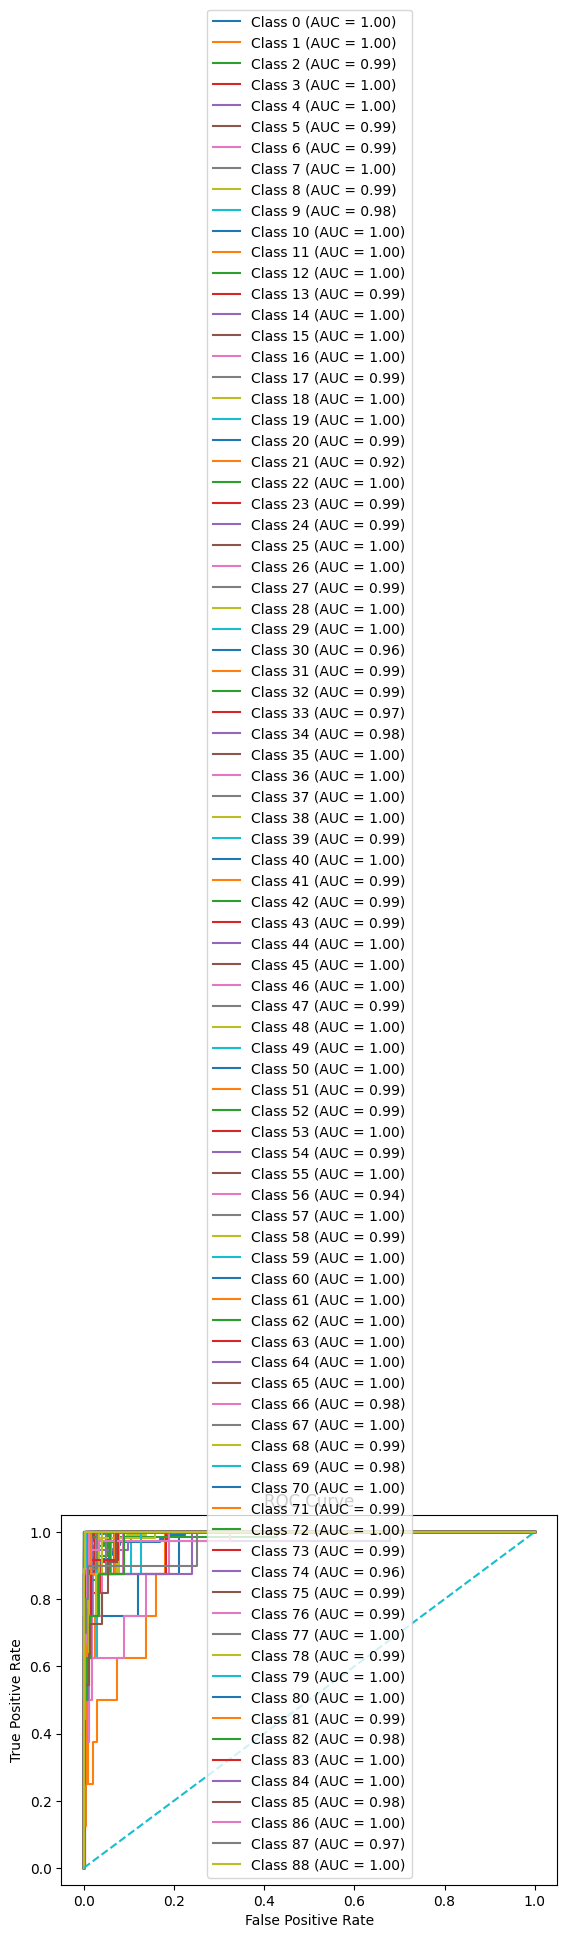

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(test_dataset.classes)

y_true = []
y_score = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Plot ROC
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
from sklearn.preprocessing import label_binarize

num_classes = y_score.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
y_true_flat = y_true_bin.ravel()
y_score_flat = y_score.ravel()
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true_flat, y_score_flat)

# F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# fix size mismatch
thresholds = np.append(thresholds, 1.0)

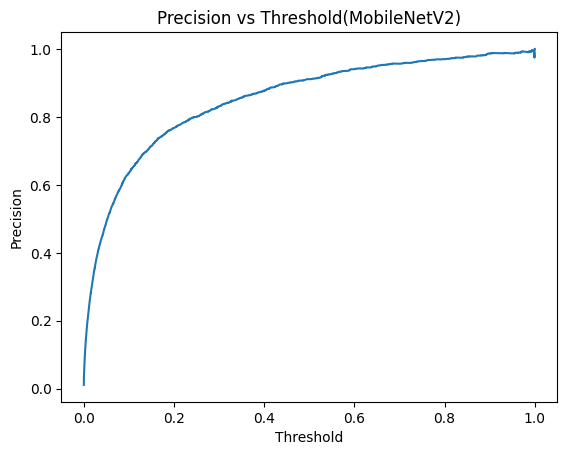

In [49]:
plt.figure()
plt.plot(thresholds, precision)
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold(MobileNetV2)")
plt.show()

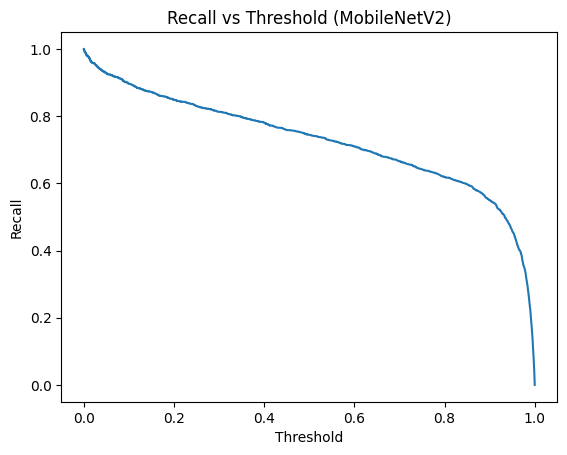

In [50]:
plt.figure()
plt.plot(thresholds, recall)
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold (MobileNetV2)")
plt.show()

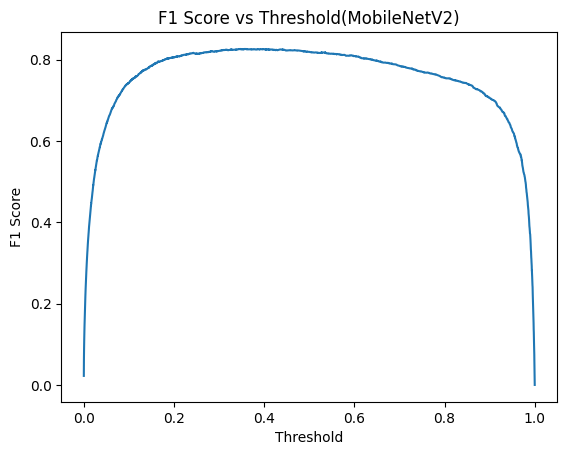

In [51]:
plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold(MobileNetV2)")
plt.show()

In [52]:
import random
import matplotlib.pyplot as plt

classes = test_dataset.classes

def show_random_predictions(model, dataset, num_images=6):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    for idx in indices:
        image, label = dataset[idx]

        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_img)
            _, pred = torch.max(outputs, 1)

        img = image.permute(1, 2, 0).numpy()

        # Unnormalize
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = img.clip(0, 1)

        plt.imshow(img)
        plt.title(f"Pred: {classes[pred.item()]} | True: {classes[label]}")
        plt.axis('off')
        plt.show()

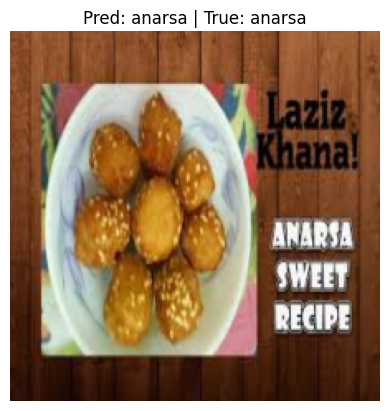

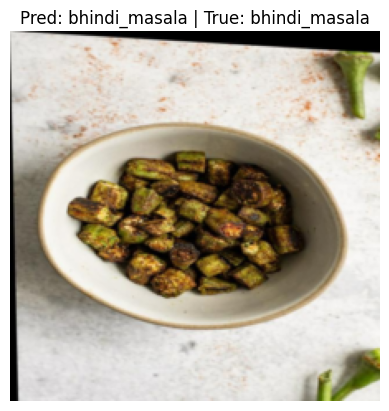

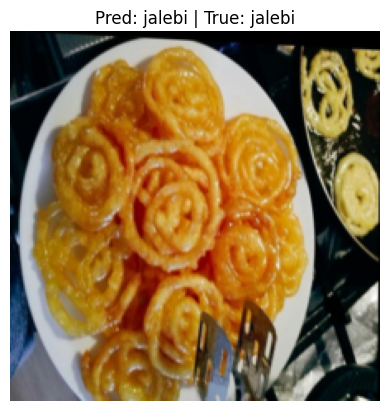

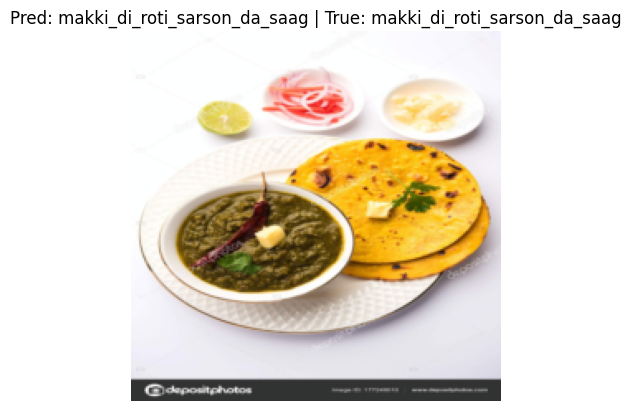

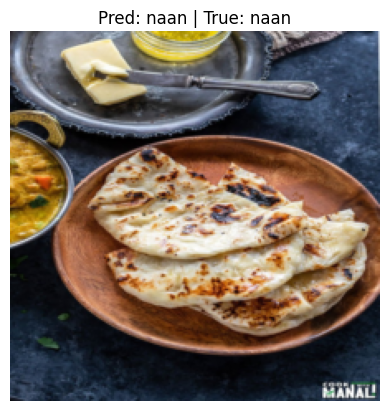

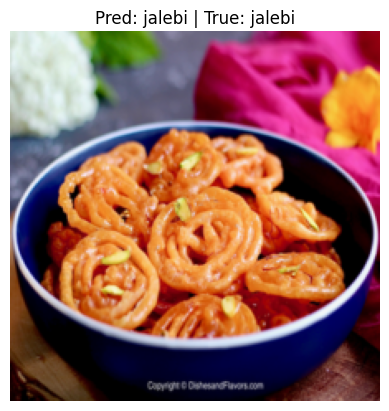

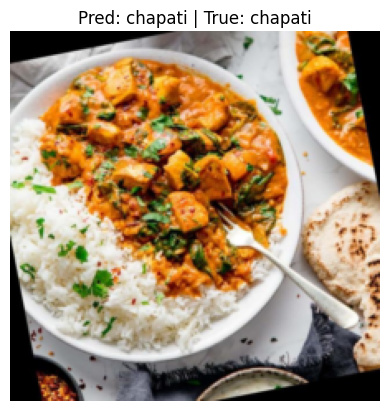

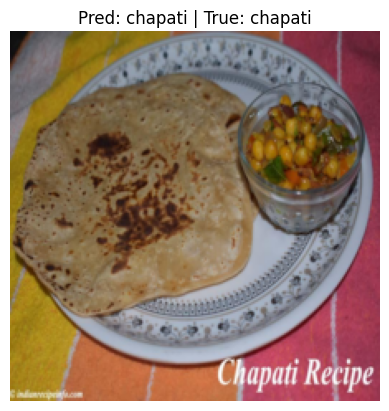

In [61]:
show_random_predictions(model, test_dataset, num_images=8)